# 03 — Descriptive EDA

Visual inspection of the daily-rollup output from notebook 02. The goal is to make data-quality issues visible before any modeling.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Walk up from CWD until pyproject.toml is found (robust to any CWD inside the repo)
def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / 'pyproject.toml').exists():
            return p
    return start

REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

df = pd.read_parquet(REPO_ROOT / 'notebooks' / 'predictions' / 'daily_rollup.parquet')
print(f'REPO_ROOT: {REPO_ROOT}')
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
df.head()

REPO_ROOT: /opt/foodlog
Shape: (61, 22)
Date range: 2026-03-20 00:00:00 to 2026-05-19 00:00:00


,intake_kcal,protein_g,carb_g,fat_g,sodium_mg,meal_types_logged,intake_coverage,intake_logged,steps,active_kcal_fitbit,...,vigorous_min,cardio_min,weight_kg,bf_pct,n_weighins,rhr_bpm,sleep_total_h_prev_night,workout_kcal,workout_min,reference_weight_kg
date,,,,,,,,,,,,,,,,,,,,,
2026-03-20,NaN,NaN,NaN,NaN,NaN,,0.0,False,NaN,NaN,...,0,0,NaN,NaN,0,67.0,NaN,0.0,0,80.0
2026-03-21,NaN,NaN,NaN,NaN,NaN,,0.0,False,NaN,NaN,...,0,0,NaN,NaN,0,NaN,NaN,0.0,0,80.0
2026-03-22,NaN,NaN,NaN,NaN,NaN,,0.0,False,NaN,NaN,...,0,0,NaN,NaN,0,67.0,NaN,0.0,0,80.0
2026-03-23,NaN,NaN,NaN,NaN,NaN,,0.0,False,NaN,NaN,...,0,2,NaN,NaN,0,68.0,NaN,0.0,0,80.0
2026-03-24,NaN,NaN,NaN,NaN,NaN,,0.0,False,NaN,NaN,...,0,0,NaN,NaN,0,69.0,8.316667,0.0,0,80.0


## Missingness map

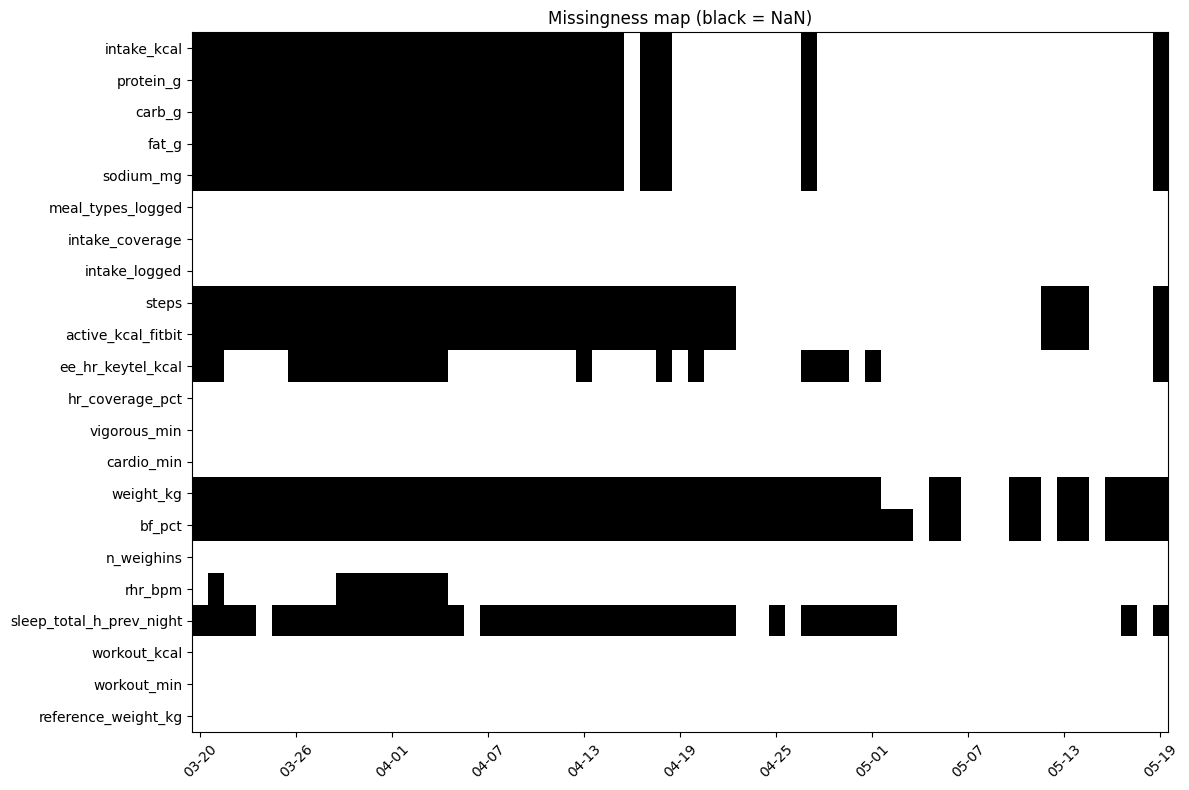

In [2]:
fig, ax = plt.subplots(figsize=(12, 8))
missing_matrix = df.isna().astype(int).T
ax.imshow(missing_matrix.values, aspect='auto', cmap='Greys', interpolation='nearest')
ax.set_yticks(range(len(missing_matrix.index)))
ax.set_yticklabels(missing_matrix.index)
ax.set_xticks(range(0, len(df), max(1, len(df)//10)))
ax.set_xticklabels([d.strftime('%m-%d') for d in df.index[::max(1, len(df)//10)]], rotation=45)
ax.set_title('Missingness map (black = NaN)')
plt.tight_layout()
plt.show()

## HR coverage and intake coverage distributions

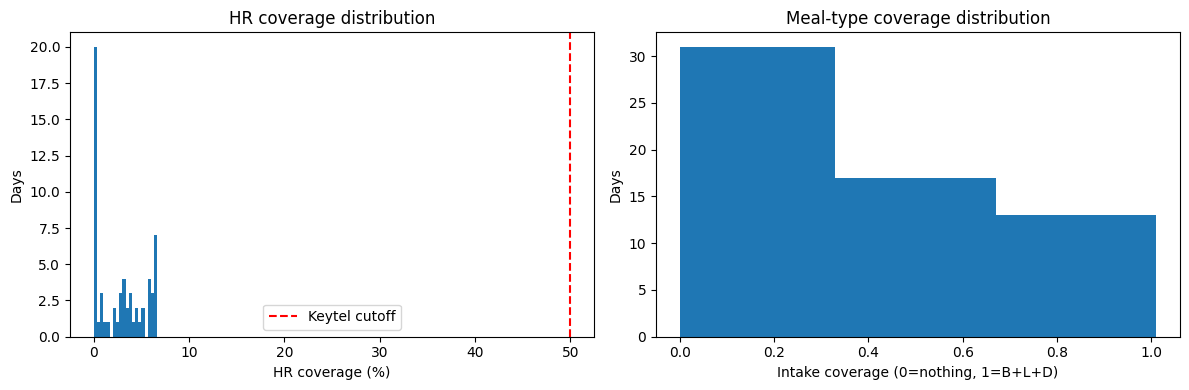


Sample meal_types_logged values: {'': 31, 'dinner,lunch,snack': 9, 'breakfast,dinner,lunch,snack': 7, 'breakfast,dinner,lunch': 6, 'breakfast,lunch': 2, 'breakfast,lunch,snack': 2, 'lunch': 1, 'dinner': 1}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['hr_coverage_pct'].dropna(), bins=20)
axes[0].set_xlabel('HR coverage (%)')
axes[0].set_ylabel('Days')
axes[0].set_title('HR coverage distribution')
axes[0].axvline(50, color='red', linestyle='--', label='Keytel cutoff')
axes[0].legend()

# intake_coverage is a float (0.0–1.0) — fraction of canonical meal types logged
# meal_types_logged is a comma-joined string in the parquet (e.g. 'breakfast,lunch')
axes[1].hist(df['intake_coverage'].dropna(), bins=[0, 0.33, 0.67, 1.01])
axes[1].set_xlabel('Intake coverage (0=nothing, 1=B+L+D)')
axes[1].set_ylabel('Days')
axes[1].set_title('Meal-type coverage distribution')
plt.tight_layout()
plt.show()

print('\nSample meal_types_logged values:', df['meal_types_logged'].value_counts().head(8).to_dict())

## Weight series with running mean

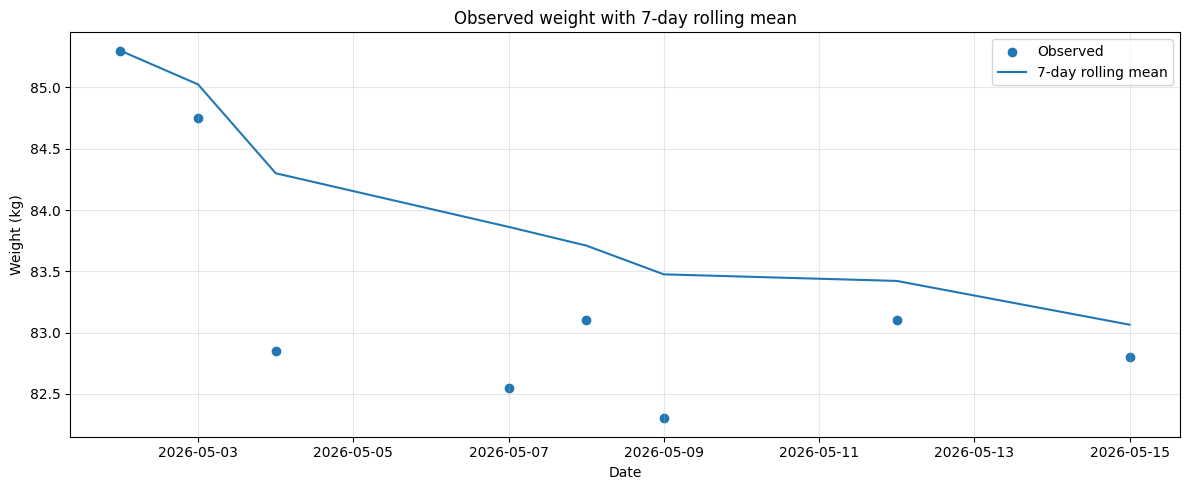

Weight observations: 8/61 days
Weight range: 82.3 – 85.3 kg


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
weighed = df.dropna(subset=['weight_kg'])
ax.scatter(weighed.index, weighed['weight_kg'], label='Observed')
if len(weighed) >= 3:
    ax.plot(weighed.index, weighed['weight_kg'].rolling(7, min_periods=1).mean(), label='7-day rolling mean')
ax.set_ylabel('Weight (kg)')
ax.set_xlabel('Date')
ax.set_title('Observed weight with 7-day rolling mean')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Weight observations: {len(weighed)}/{len(df)} days')
print(f'Weight range: {weighed["weight_kg"].min():.1f} \u2013 {weighed["weight_kg"].max():.1f} kg')

## Energy balance proxy (intake vs daily activity + workouts)

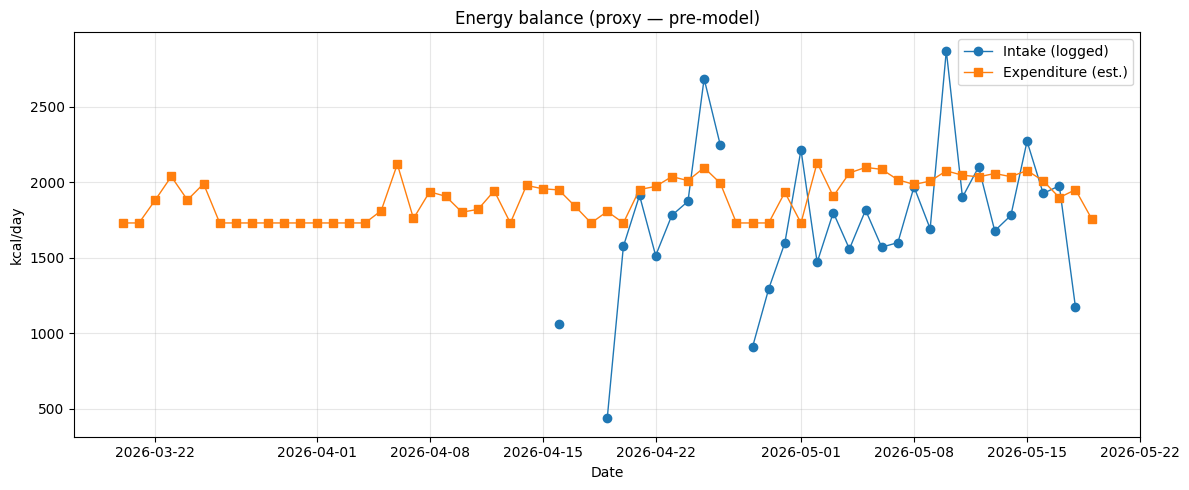

Days with both intake + expenditure: 30
Mean balance (intake - expenditure): -230 kcal/day
Std: 449 kcal/day


In [5]:
from body_sim.rmr import mifflin_st_jeor
from body_sim.config import DEFAULT_PROFILE

df = df.copy()
df['rmr_estimate'] = df['reference_weight_kg'].apply(
    lambda w: mifflin_st_jeor(w, DEFAULT_PROFILE['height_cm'], DEFAULT_PROFILE['age'], DEFAULT_PROFILE['sex'])
)
df['activity_estimate'] = df['ee_hr_keytel_kcal'].fillna(df['workout_kcal'] + df['steps'].fillna(0) * 0.04)
df['expenditure_estimate'] = df['rmr_estimate'] + df['activity_estimate']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['intake_kcal'], label='Intake (logged)', marker='o', linewidth=1)
ax.plot(df.index, df['expenditure_estimate'], label='Expenditure (est.)', marker='s', linewidth=1)
ax.set_ylabel('kcal/day')
ax.set_xlabel('Date')
ax.set_title('Energy balance (proxy \u2014 pre-model)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

both_present = df.dropna(subset=['intake_kcal', 'expenditure_estimate'])
if len(both_present) > 0:
    balance = both_present['intake_kcal'] - both_present['expenditure_estimate']
    print(f'Days with both intake + expenditure: {len(both_present)}')
    print(f'Mean balance (intake - expenditure): {balance.mean():.0f} kcal/day')
    print(f'Std: {balance.std():.0f} kcal/day')